In [63]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df=pd.read_csv('tiktok.csv')
print(df.shape)
print(df.columns.tolist())
df.head()


(6746, 23)
['track_id', 'track_name', 'artist_id', 'artist_name', 'album_id', 'duration', 'release_date', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'playlist_id', 'playlist_name', 'duration_mins', 'genre']


,track_id,track_name,artist_id,artist_name,album_id,duration,release_date,popularity,danceability,energy,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,playlist_id,playlist_name,duration_mins,genre
0,6kVuF2PYLuvl9T85XjNbaO,Lay It Down Gmix - Main,1Xfmvd48oOhEWkscWyEbh9,Lloyd,43C6GVlhXG4KfZuEbxty3r,302186,2011-01-01,28,0.597,0.800,...,0.3120,0.0461,0.0,0.1800,0.565,155.932,6kVuF2PYLuvl9T85XjNbaO,6kVuF2PYLuvl9T85XjNbaO,5.036433,TIKTOK DANCE
1,1RGIjMFMgJxkZHMDXVYzOJ,Bartender (feat. Akon),3aQeKQSyrW4qWr35idm0cy,T-Pain,6CrSEKCF4TYrbSIitegb3h,238800,2007-06-05,75,0.832,0.391,...,0.0628,0.0564,0.0,0.2240,0.436,104.961,1RGIjMFMgJxkZHMDXVYzOJ,1RGIjMFMgJxkZHMDXVYzOJ,3.980000,TIKTOK DANCE
2,1RGIjMFMgJxkZHMDXVYzOJ,Bartender (feat. Akon),3aQeKQSyrW4qWr35idm0cy,T-Pain,6CrSEKCF4TYrbSIitegb3h,238800,2007-06-05,75,0.832,0.391,...,0.0628,0.0564,0.0,0.2240,0.436,104.961,1RGIjMFMgJxkZHMDXVYzOJ,1RGIjMFMgJxkZHMDXVYzOJ,3.980000,TIKTOK DANCE
3,1dIWPXMX4kRHj6Dt2DStUQ,Chosen (feat. Ty Dolla $ign),4qXC0i02bSFstECuXP2ZpL,Blxst,7AwrgenNcTAJlJF3pKL0Qr,161684,2020-12-04,76,0.571,0.767,...,0.2870,0.3360,0.0,0.0809,0.605,93.421,1dIWPXMX4kRHj6Dt2DStUQ,1dIWPXMX4kRHj6Dt2DStUQ,2.694733,TIKTOK DANCE
4,4QVS8YCpK71R4FsxSMCjhP,Tie Me Down (with Elley Duhé),2ZRQcIgzPCVaT9XKhXZIzh,Gryffin,69t8rpgBN1ov5kCU6LDMuR,218295,2018-08-03,72,0.548,0.839,...,0.0644,0.1350,0.0,0.1020,0.314,98.932,4QVS8YCpK71R4FsxSMCjhP,4QVS8YCpK71R4FsxSMCjhP,3.638250,TIKTOK DANCE


In [64]:
# Remove duplicates
df=df.drop_duplicates(subset='track_id')
print(f"After removing duplicates: {df.shape}")

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check popularity distribution
print("\nPopularity stats:")
print(df['popularity'].describe())

After removing duplicates: (3560, 23)

Missing values:
track_id            0
track_name          0
artist_id           0
artist_name         0
album_id            0
duration            0
release_date        0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
playlist_id         0
playlist_name       0
duration_mins       0
genre               0
dtype: int64

Popularity stats:
count    3560.000000
mean       50.539326
std        24.731639
min         0.000000
25%        35.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: popularity, dtype: float64


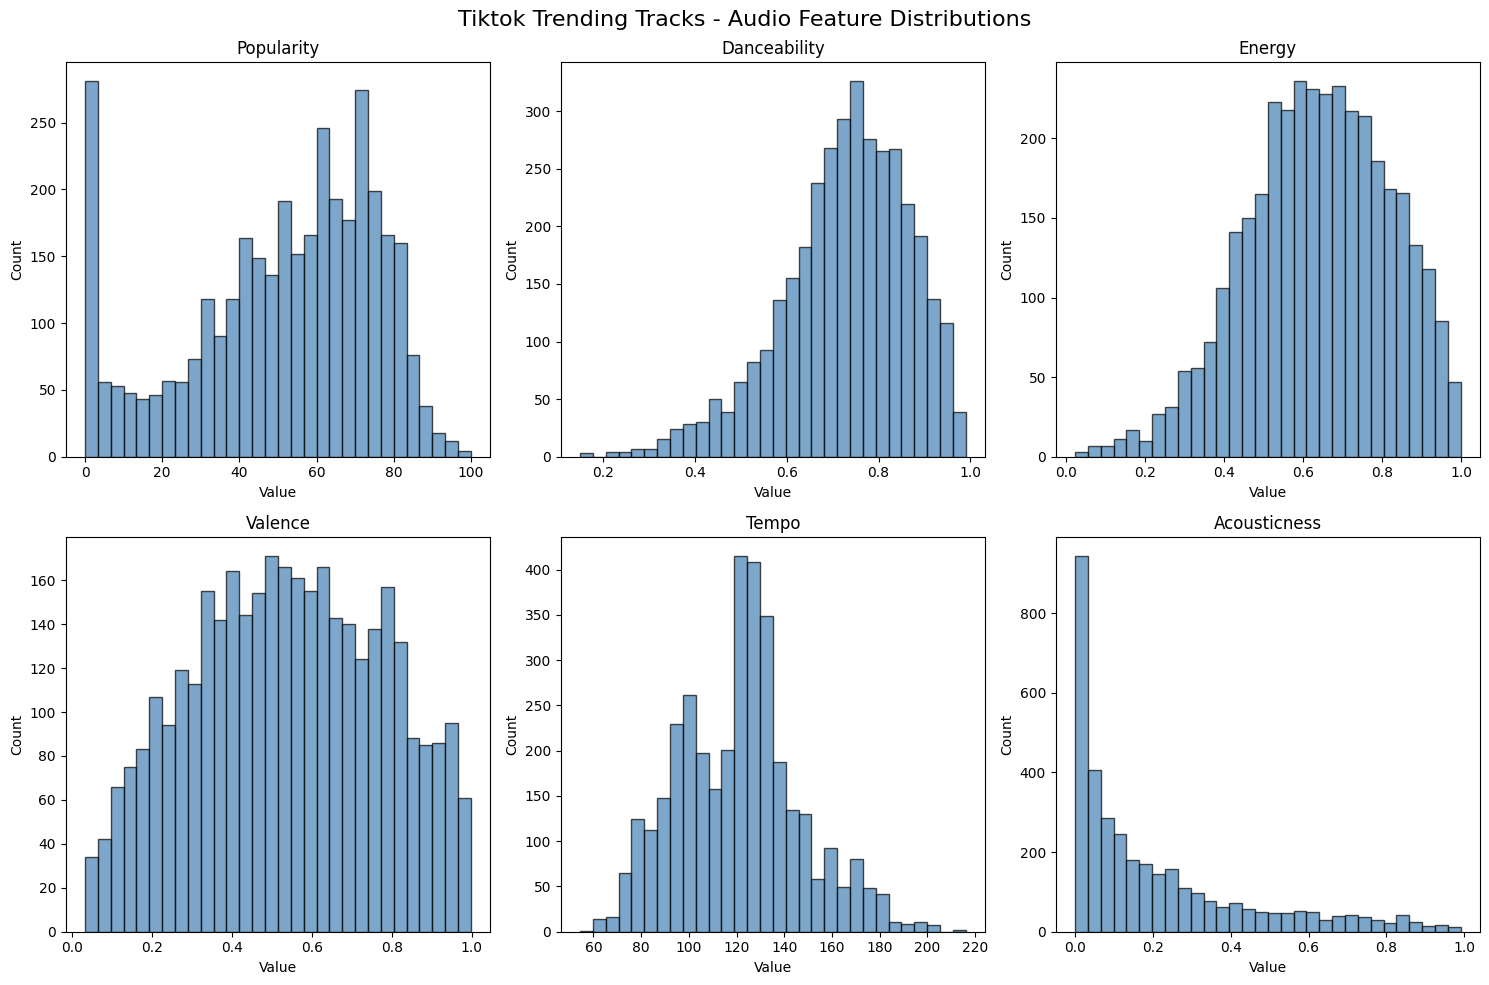

In [65]:
fig, axes=plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Tiktok Trending Tracks - Audio Feature Distributions', fontsize=16)

features=['popularity', 'danceability', 'energy', 'valence', 'tempo', 'acousticness']

for ax, feature in zip(axes.flatten(), features):
    ax.hist(df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(feature.capitalize())
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()



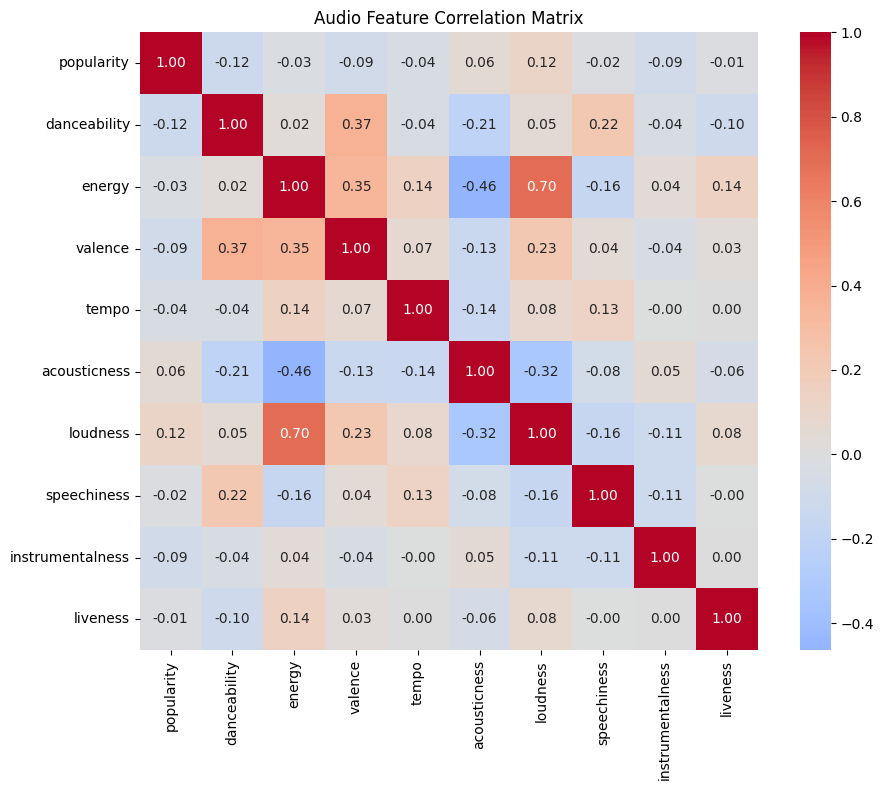

In [66]:
audio_features=['popularity', 'danceability', 'energy', 'valence', 'tempo', 'acousticness','loudness', 'speechiness', 'instrumentalness', 'liveness']

corr_matrix= df[audio_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Audio Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()


In [67]:
# Define a "hit" as popularity >= 60
df['is_hit'] = (df['popularity'] >= 60).astype(int)

print(f"Hits (popularity >= 60): {df['is_hit'].sum()}")
print(f"Non-hits: {(df['is_hit']==0).sum()}")
print(f"Hit rate: {df['is_hit'].mean():.1%}")

Hits (popularity >= 60): 1563
Non-hits: 1997
Hit rate: 43.9%


In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define features and target 
features = ['danceability', 'energy', 'valence', 'tempo', 
            'acousticness', 'loudness', 'speechiness', 
            'instrumentalness', 'liveness']

X=df[features]
y=df['is_hit']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")



Training samples: 2848
Test samples: 712


In [69]:
# Train the model
model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Test it
y_pred= model.predict(X_test)

# Results
print(F"Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print("\nDetailed Results:")
print(classification_report(y_test, y_pred, target_names=['Not Hit', 'Hit']))


Accuracy: 60.1%

Detailed Results:
              precision    recall  f1-score   support

     Not Hit       0.63      0.67      0.65       390
         Hit       0.56      0.52      0.54       322

    accuracy                           0.60       712
   macro avg       0.60      0.59      0.59       712
weighted avg       0.60      0.60      0.60       712



In [70]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Try multiple models 
models={
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)

}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred=m.predict(X_test)
    acc=accuracy_score(y_test, pred)
    print(f"{name}: {acc:.1%}")
    

Random Forest: 60.1%
Gradient Boosting: 60.0%
Logistic Regression: 59.4%


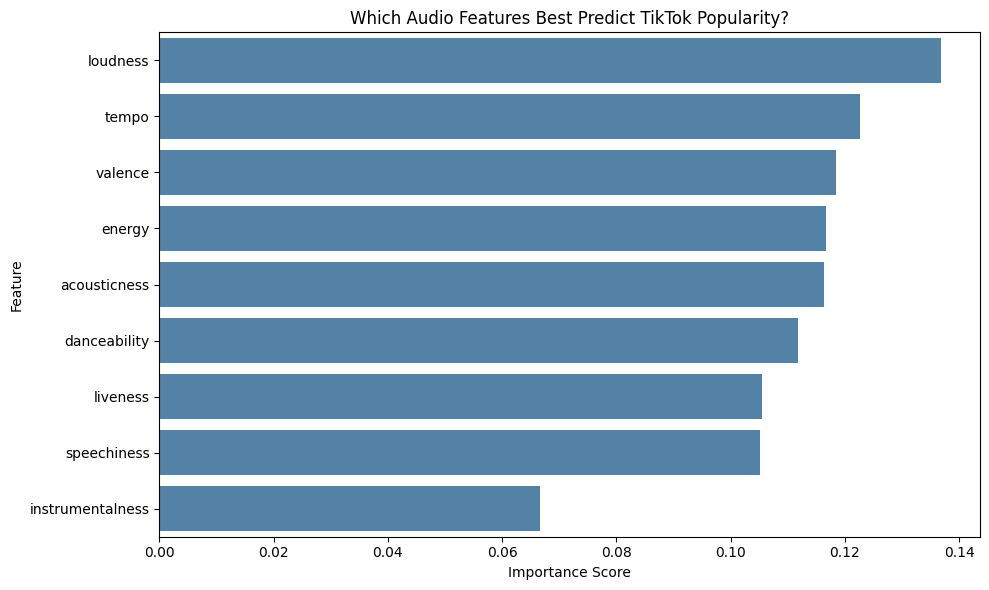

            feature  importance
5          loudness    0.136819
3             tempo    0.122613
2           valence    0.118428
1            energy    0.116765
4      acousticness    0.116292
0      danceability    0.111730
8          liveness    0.105569
6       speechiness    0.105143
7  instrumentalness    0.066642


In [71]:
# Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance' : model.feature_importances_
    }).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', color='steelblue')
plt.title('Which Audio Features Best Predict TikTok Popularity?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(importance_df)

In [72]:
# Load Spotify 2024 dataset
spotify_df = pd.read_csv('Most Streamed Spotify Songs 2024.csv', encoding='latin-1')
spotify_df=spotify_df.drop_duplicates(subset='Track')
print(spotify_df.shape)
print(spotify_df.columns.tolist())


(4370, 29)
['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC', 'All Time Rank', 'Track Score', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity', 'Explicit Track']


In [73]:
# Check TikTok and Spotify columns
print(spotify_df[['Track', 'Artist', 'Spotify Streams', 
                   'Spotify Popularity', 'TikTok Views', 
                   'TikTok Likes', 'TikTok Posts']].head(10))

# Check for missing values in key columns
print("\nMissing values:")
print(spotify_df[['Spotify Streams', 'Spotify Popularity', 
                   'TikTok Views', 'TikTok Likes', 
                   'TikTok Posts']].isnull().sum())



                        Track          Artist Spotify Streams  \
0         MILLION DOLLAR BABY   Tommy Richman     390,470,936   
1                 Not Like Us  Kendrick Lamar     323,703,884   
2  i like the way you kiss me         Artemas     601,309,283   
3                     Flowers     Miley Cyrus   2,031,280,633   
4                     Houdini          Eminem     107,034,922   
5                 Lovin On Me     Jack Harlow     670,665,438   
6            Beautiful Things    Benson Boone     900,158,751   
7                   Gata Only      FloyyMenor     675,079,153   
8        Danza Kuduro - Cover   MUSIC LAB JPN   1,653,018,119   
9  BAND4BAND (feat. Lil Baby)     Central Cee      90,676,573   

   Spotify Popularity    TikTok Views   TikTok Likes TikTok Posts  
0                92.0   5,332,281,936    651,565,900    5,767,700  
1                92.0     208,339,025     35,223,547      674,700  
2                92.0   3,369,120,610    275,154,237    3,025,400  
3           

In [74]:
# Convert number columns from text to actual numbers
tiktok_cols= ['Spotify Streams', 'Spotify Popularity', 'TikTok Views', 'TikTok Likes', 'TikTok Posts']

for col in tiktok_cols: 
    spotify_df[col]=pd.to_numeric(
        spotify_df[col].astype(str).str.replace(',', ''),
        errors='coerce'
    )

# Fill missing Tiktok values with 0
spotify_df['TikTok Views']=spotify_df['TikTok Views'].fillna(0)
spotify_df['TikTok Likes']= spotify_df['TikTok Likes'].fillna(0)
spotify_df['TikTok Posts']=spotify_df['TikTok Posts'].fillna(0)

print("Sample:")
print(spotify_df[['Track', 'Spotify Streams', 'TikTok Views']].head(3))


Sample:
                        Track  Spotify Streams  TikTok Views
0         MILLION DOLLAR BABY      390470936.0  5.332282e+09
1                 Not Like Us      323703884.0  2.083390e+08
2  i like the way you kiss me      601309283.0  3.369121e+09


In [75]:
# Create platform dominance categories
spotify_df['combined_score'] = (
    spotify_df['TikTok Views'] / spotify_df['TikTok Views'].max() +
    spotify_df['Spotify Streams'] / spotify_df['Spotify Streams'].max()
)
spotify_df['tiktok_viral'] = (
    spotify_df['TikTok Views']> spotify_df['TikTok Views'].quantile(0.75)).astype(int)

spotify_df['spotify_dominant']=(
    spotify_df['Spotify Streams'] > spotify_df['Spotify Streams'].quantile(0.75)).astype(int)

# Create 4 categories
def categorize(row):
    if row['tiktok_viral']==1 and row['spotify_dominant']==1:
        return 'Both Platforms'
    elif row['tiktok_viral'] == 1 and row['spotify_dominant']==0:
        return 'TikTok Only'
    elif row['tiktok_viral']== 0 and row['spotify_dominant']==1:
        return 'Spotify Only'
    else:
        return 'Neither'

spotify_df['platform_category'] = spotify_df.apply(categorize, axis=1)

print(spotify_df['platform_category'].value_counts())

platform_category
Neither           2648
TikTok Only        654
Spotify Only       629
Both Platforms     439
Name: count, dtype: int64


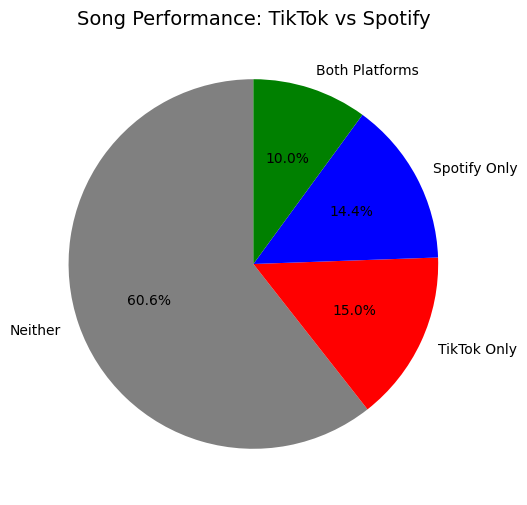

In [76]:
# Visualize platform categories
plt.figure(figsize=(10, 6))
colors=['green', 'red', 'blue', 'gray']
category_counts=spotify_df['platform_category'].value_counts()

plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', colors=['grey', 'red', 'blue', 'green'],
        startangle=90 )

plt.title('Song Performance: TikTok vs Spotify', fontsize=14)
plt.savefig('platform_comparison.png', dpi=150)
plt.show()


In [77]:
# Compare average Spotify Popularity across categories
comparison = spotify_df.groupby('platform_category').agg({'Spotify Popularity': 'mean', 'TikTok Views': 'mean', 'Spotify Streams': 'mean'}).round(2)

print(comparison)

                   Spotify Popularity  TikTok Views  Spotify Streams
platform_category                                                   
Both Platforms                  73.26  3.000528e+09     1.239927e+09
Neither                         60.75  1.056383e+08     1.692264e+08
Spotify Only                    70.55  2.299545e+08     1.099058e+09
TikTok Only                     59.63  3.569466e+09     2.544837e+08


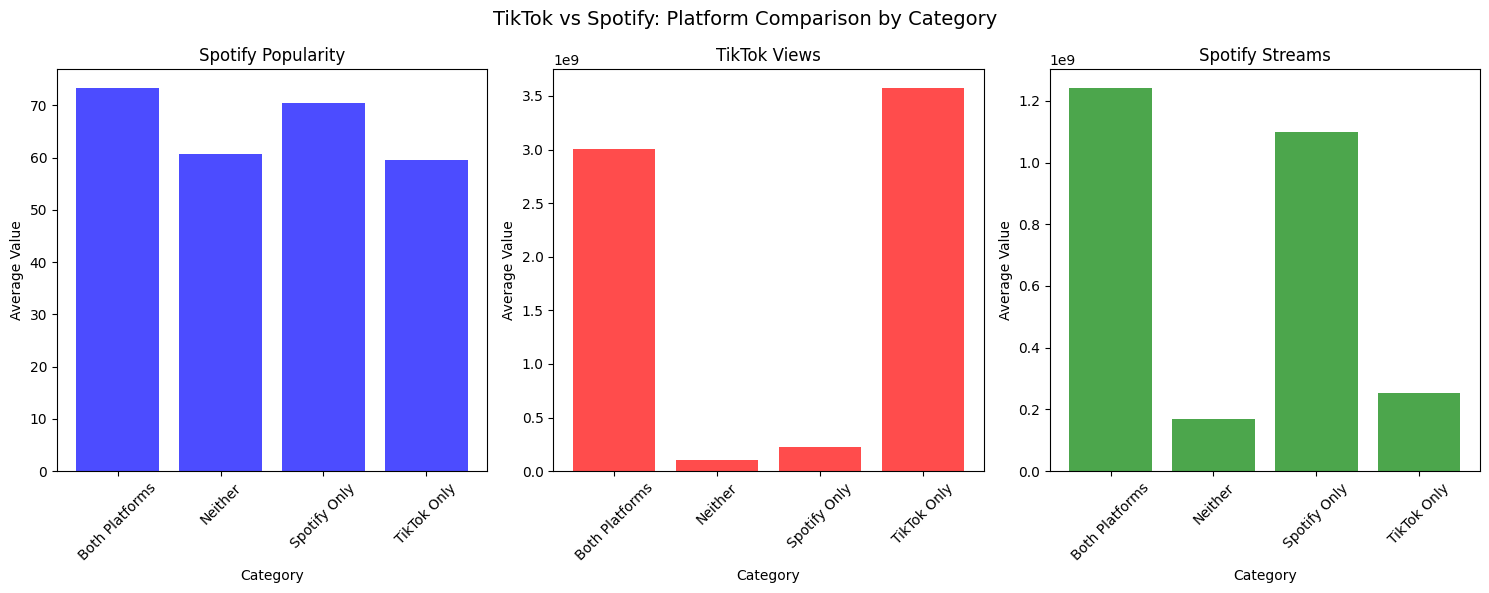

In [78]:
fig, axes =plt.subplots(1, 3, figsize=(15,6))
fig.suptitle('TikTok vs Spotify: Platform Comparison by Category', fontsize=14)

metrics = ['Spotify Popularity', 'TikTok Views', 'Spotify Streams']
colors=['blue', 'red', 'green']

for ax, metric, color in zip(axes, metrics, colors):
    data=spotify_df.groupby('platform_category')[metric].mean()
    ax.bar(data.index, data.values, color=color, alpha=0.7)
    ax.set_title(metric)
    ax.set_xlabel('Category')
    ax.set_ylabel('Average Value')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('platgorm_metrics.png', dpi=150)
plt.show()



In [79]:
print(spotify_df['platform_category'].value_counts())
print("\n")
comparison = spotify_df.groupby('platform_category').agg({
    'Spotify Popularity': 'mean',
    'TikTok Views': 'mean',
    'Spotify Streams': 'mean'
}).round(2)
print(comparison)

platform_category
Neither           2648
TikTok Only        654
Spotify Only       629
Both Platforms     439
Name: count, dtype: int64


                   Spotify Popularity  TikTok Views  Spotify Streams
platform_category                                                   
Both Platforms                  73.26  3.000528e+09     1.239927e+09
Neither                         60.75  1.056383e+08     1.692264e+08
Spotify Only                    70.55  2.299545e+08     1.099058e+09
TikTok Only                     59.63  3.569466e+09     2.544837e+08
